# Informe 6: Reducción de la Dimensionalidad

- **Asignatura:** Inteligencia Artificial
- **Grupo:** 06
- **Integrantes:** Bautista De la Cruz Claudia Daniela, Carrascal Castro Priscila Maria, Ccahuana Quiñones Judith Valeria, Gil Sixi Alberto Luis, Medrano Ayma Nikol Arlet, Rosales Trinidad Jeanmarco Miguel, Saire Tello Fernando José

## Empresa: AndinaSense

AndinaSense es una empresa de agricultura de precisión que brinda servicios de monitoreo a agroexportadoras de arándano en los valles de la costa norte del Perú (La Libertad, Lambayeque e Ica). Mediante sensores instalados en las parcelas, registra las condiciones de suelo, clima y manejo de cada una. Con miles de parcelas bajo monitoreo, necesita agruparlas en perfiles que permitan un manejo diferenciado y eficiente, en lugar de tratarlas todas por igual.

### Planteamiento del informe

**Objetivo del informe:** Reducir las condiciones de suelo, clima y manejo de las parcelas de arándano a un espacio de pocas dimensiones mediante PCA y t-SNE, para visualizar la estructura de los datos e interpretar qué factores explican la mayor variabilidad entre parcelas.

**Pregunta de negocio:** ¿Qué factores concentran la mayor variación entre las parcelas y cómo se ven sus perfiles al representarlos en un mapa de dos dimensiones?

**Por qué aporta valor:** Resumir muchas variables de sensor en pocos factores permite a AndinaSense visualizar en un solo mapa cómo se distribuyen sus parcelas y comunicar de forma clara los perfiles de manejo al equipo agronómico. Además, identificar qué condiciones concentran la mayor variabilidad ayuda a priorizar en qué mediciones vale la pena invertir para diferenciar las parcelas.

## Generación y carga del dataset

El dataset `andinasense_parcelas.csv` es sintético y propio del grupo. Contiene 1500 parcelas (filas) y 13 variables (columnas), con mezcla de numéricas y categóricas. La variable objetivo continua es `rendimiento_kg_ha` y la categórica es `calidad_cosecha` (Baja, Media, Alta).

Generación (reproducible con semilla SEED = 42):

- Las parcelas provienen de 4 zonas agroecológicas latentes con proporciones controladas (Óptima 35%, Estrés Hídrico 25%, Desbalance de pH 20%, Multi-estrés Leve 20%). La zona se usa solo para generar y no aparece como columna.
- Cada zona tiene un perfil de medias por variable de suelo, clima y manejo, con dispersión calibrada para un solapamiento realista (correlaciones y ruido, no grupos perfectos).
- `rendimiento_kg_ha` se deriva de una función de respuesta agronómica con penalización cuadrática (óptimo de temperatura 20 °C y de pH 5.5) más ruido gaussiano; `calidad_cosecha` se obtiene por terciles del rendimiento.
- Se introdujeron nulos y valores atípicos intencionales en las columnas de sensores para exigir tratamiento en el preprocesamiento.

El script generador completo, reproducible con la misma semilla, está en el repositorio del proyecto (carpeta `generador_dataset`). Este notebook no regenera los datos: solo carga el CSV en la siguiente celda.

## 1. Importar librerías y cargar los datos

In [1]:
# Evitar el warning de KMeans en Windows (MKL)
import os
os.environ['OMP_NUM_THREADS'] = '6'

# Librerías base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Agrupamiento (para recuperar los grupos del Informe 5 y proyectarlos)
from sklearn.cluster import KMeans

# Reducción de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Semilla global para reproducibilidad
SEED = 42

# Estilo de gráficos consistente y legible
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# Cargar el dataset (debe estar en la misma carpeta que este notebook)
ARCHIVO = 'andinasense_parcelas.csv'
if not os.path.exists(ARCHIVO):
    raise FileNotFoundError(
        f"No se encontró '{ARCHIVO}'. "
        f"Coloca el CSV en la misma carpeta que este notebook y vuelve a ejecutar."
    )
df = pd.read_csv(ARCHIVO)
print('Dimensiones:', df.shape)
df.head()

Dimensiones: (1500, 13)


,id_parcela,region,variedad,superficie_ha,temp_promedio,humedad_suelo,ph_suelo,horas_sol,riego_mm,fertilizante_kg,densidad_plantas,rendimiento_kg_ha,calidad_cosecha
0,PARC-00001,Lambayeque,Emerald,10.55,19.5,55.5,6.72,9.6,523.0,282.0,4443.0,8476.0,Baja
1,PARC-00002,Lambayeque,Biloxi,4.33,22.0,42.1,5.48,8.4,698.0,166.0,4204.0,8542.0,Baja
2,PARC-00003,La Libertad,Ventura,5.04,21.0,40.7,6.22,7.7,619.0,253.0,3547.0,9270.0,Alta
3,PARC-00004,La Libertad,Rocio,7.19,20.4,52.1,6.63,9.2,507.0,277.0,4229.0,8624.0,Media
4,PARC-00005,Lambayeque,Biloxi,2.76,20.8,56.9,5.33,9.2,592.0,201.0,3778.0,9033.0,Media


## 2. Preparación de los datos: corrección, selección y escalamiento

In [2]:
# Corrección de valores imposibles: humedad de suelo > 100% no existe;
# pH de suelo agrícola realista entre 3.5 y 9. Se convierten a NaN para imputarlos.
df.loc[df['humedad_suelo'] > 100, 'humedad_suelo'] = np.nan
df.loc[(df['ph_suelo'] < 3.5) | (df['ph_suelo'] > 9), 'ph_suelo'] = np.nan

# Las 7 variables de condición que describen suelo, clima y manejo de la parcela.
# Se excluyen superficie_ha (contexto) y rendimiento_kg_ha / calidad_cosecha (resultados).
variables = ['temp_promedio', 'humedad_suelo', 'ph_suelo', 'horas_sol',
             'riego_mm', 'fertilizante_kg', 'densidad_plantas']
X = df[variables].copy()

# PCA y t-SNE son sensibles a la escala, así que se estandariza.
# La imputación con mediana y el escalado se encapsulan en un Pipeline reproducible.
preprocesador = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])
X_scaled = preprocesador.fit_transform(X)

# Verificación del escalado: media ~0 y desviación ~1
print('Media tras escalar (~0):', np.round(X_scaled.mean(axis=0), 2))
print('Desv. tras escalar (~1):', np.round(X_scaled.std(axis=0), 2))

# Se recuperan los 4 perfiles de parcela obtenidos con K-Means sobre estas mismas
# variables. Sirven ÚNICAMENTE para colorear las proyecciones y evaluar si la
# reducción conserva la estructura; nunca entran como variable de PCA o t-SNE.
kmeans = KMeans(n_clusters=4, n_init=10, random_state=SEED)
grupos = kmeans.fit_predict(X_scaled)
print('\nParcelas por perfil:', np.bincount(grupos))

Media tras escalar (~0): [ 0.  0. -0.  0. -0. -0.  0.]
Desv. tras escalar (~1): [1. 1. 1. 1. 1. 1. 1.]

Parcelas por perfil: [535 307 381 277]


## 3. PCA: varianza explicada por componente

componente  varianza_explicada  varianza_acumulada
       PC1              0.3771              0.3771
       PC2              0.2574              0.6345
       PC3              0.1523              0.7868
       PC4              0.0727              0.8596
       PC5              0.0581              0.9177
       PC6              0.0437              0.9614
       PC7              0.0386              1.0000


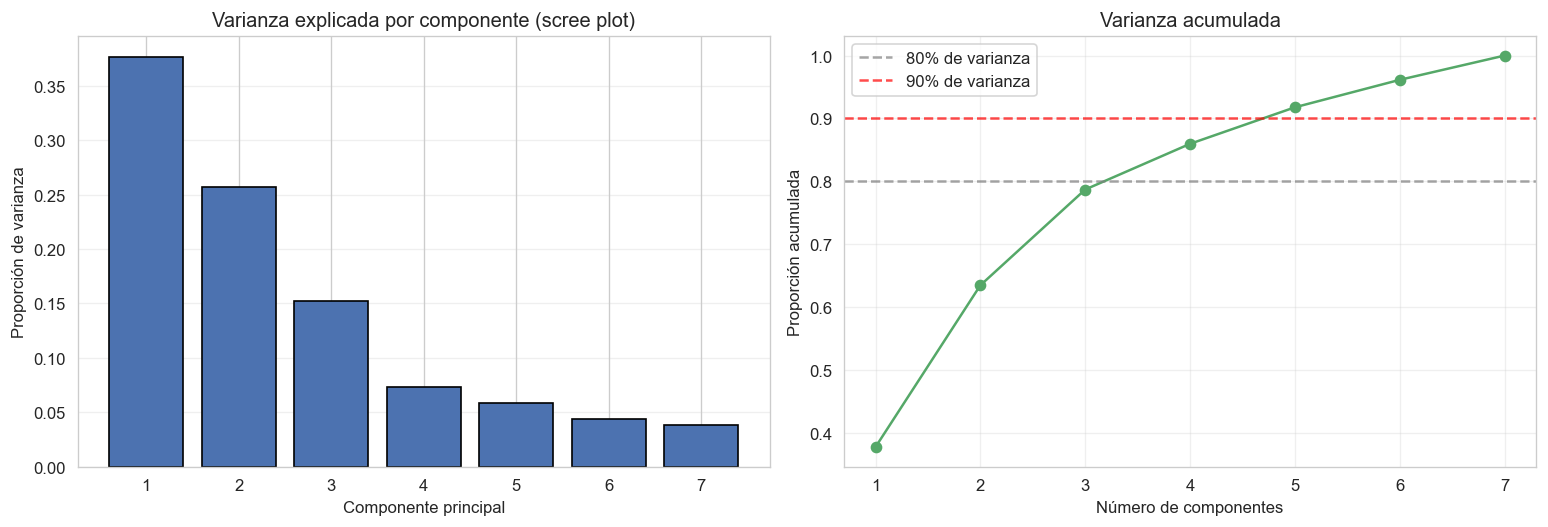

In [3]:
# Se ajusta un PCA con todos los componentes para ver cuánta varianza aporta cada uno.
pca_full = PCA(random_state=SEED).fit(X_scaled)

var_por_comp = pca_full.explained_variance_ratio_
var_acumulada = np.cumsum(var_por_comp)

# Tabla de varianza por componente y acumulada
tabla_var = pd.DataFrame({
    'componente': [f'PC{i}' for i in range(1, len(var_por_comp) + 1)],
    'varianza_explicada': np.round(var_por_comp, 4),
    'varianza_acumulada': np.round(var_acumulada, 4)
})
print(tabla_var.to_string(index=False))

# Gráfico: scree plot (varianza por componente) y varianza acumulada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.bar(range(1, len(var_por_comp) + 1), var_por_comp, color='#4C72B0', edgecolor='black')
ax1.set_title('Varianza explicada por componente (scree plot)')
ax1.set_xlabel('Componente principal'); ax1.set_ylabel('Proporción de varianza')
ax1.set_xticks(range(1, len(var_por_comp) + 1))
ax1.grid(alpha=0.3, axis='y')

ax2.plot(range(1, len(var_acumulada) + 1), var_acumulada, 'o-', color='#55A868')
ax2.axhline(0.80, color='gray', ls='--', alpha=0.7, label='80% de varianza')
ax2.axhline(0.90, color='red', ls='--', alpha=0.7, label='90% de varianza')
ax2.set_title('Varianza acumulada')
ax2.set_xlabel('Número de componentes'); ax2.set_ylabel('Proporción acumulada')
ax2.set_xticks(range(1, len(var_acumulada) + 1))
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Selección del número de componentes

In [4]:
# Se decide cuántos componentes conservar combinando tres criterios:
#   - Codo del scree plot (visto en la celda anterior).
#   - Umbral de varianza acumulada: los que capturen ~90% de la varianza.
#   - Regla de Kaiser: componentes con autovalor > 1 (sobre datos estandarizados).

comp_2d = 2
var_2d = var_acumulada[1]        # varianza acumulada hasta PC2

# Número mínimo de componentes para alcanzar el 90% de la varianza
comp_90 = int(np.argmax(var_acumulada >= 0.90) + 1)
var_90 = var_acumulada[comp_90 - 1]

# Regla de Kaiser: se conservan los componentes cuyo autovalor supera 1
autovalores = pca_full.explained_variance_
comp_kaiser = int((autovalores > 1).sum())

print(f'Para visualización 2D se usan {comp_2d} componentes '
      f'(PC1+PC2 = {var_2d*100:.1f}% de la varianza).')
print(f'Para retener el 90% de la varianza se necesitan {comp_90} componentes '
      f'(acumulada = {var_90*100:.1f}%).')
print(f'Regla de Kaiser (autovalor > 1): {comp_kaiser} componentes.')

Para visualización 2D se usan 2 componentes (PC1+PC2 = 63.5% de la varianza).
Para retener el 90% de la varianza se necesitan 5 componentes (acumulada = 91.8%).
Regla de Kaiser (autovalor > 1): 3 componentes.


### Observaciones de la selección de componentes

- El scree plot muestra un codo marcado entre el tercer y el cuarto componente: los tres primeros concentran la caída fuerte de varianza (37.7%, 25.7% y 15.2%) y a partir del cuarto el aporte marginal se vuelve pequeño y estable.
- La regla de Kaiser (autovalor > 1) coincide con el codo y señala 3 componentes: los tres primeros explican más varianza que una variable individual, mientras que del cuarto en adelante aportan menos que una sola variable original.
- Para visualización se conservan 2 componentes, que capturan el 63.5% de la variabilidad total, suficiente para representar las parcelas en un mapa plano sin perder la mayor parte de su estructura.
- Para retener información de forma más completa se requieren 5 componentes, que acumulan el 91.8% de la varianza: las 7 variables de condición se resumen en 5 factores sin perder casi nada, lo que evidencia cierta redundancia entre ellas.

## 5. Interpretación de los componentes

Cargas (loadings) de los primeros componentes:
                    PC1    PC2    PC3
temp_promedio     0.522  0.182  0.050
humedad_suelo    -0.545 -0.045 -0.145
ph_suelo         -0.147  0.589  0.303
horas_sol         0.014 -0.500  0.585
riego_mm          0.510 -0.106  0.318
fertilizante_kg  -0.085  0.563  0.418
densidad_plantas -0.377 -0.201  0.517


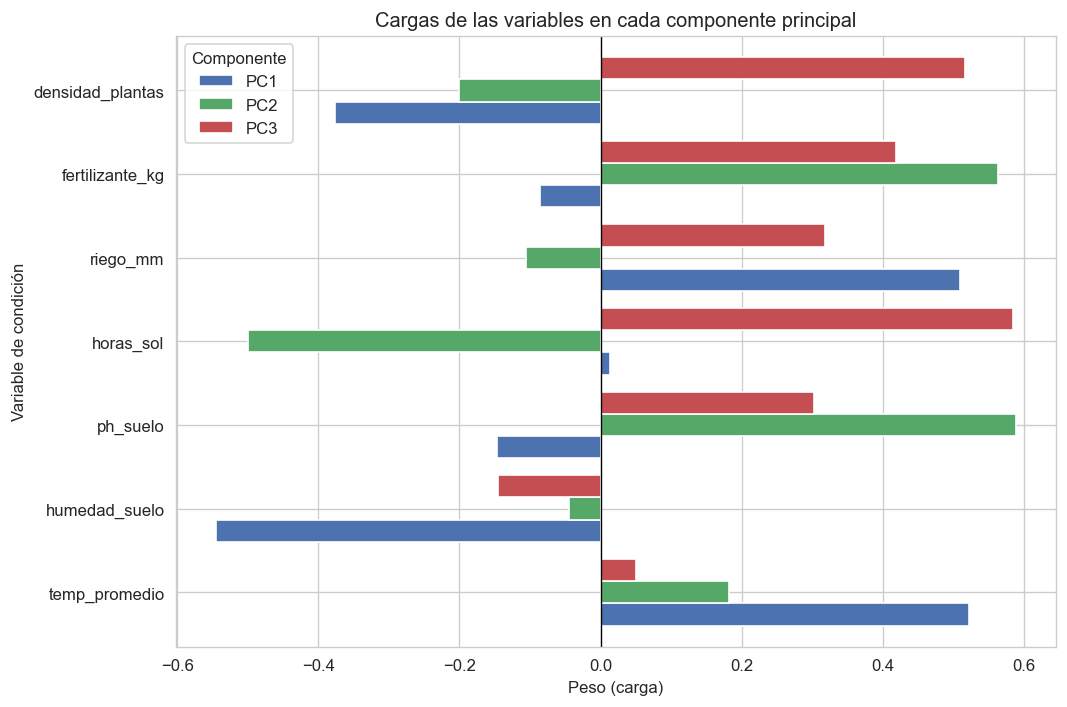

In [5]:
# Cada componente es una combinación lineal de las 7 variables originales.
# Las cargas (loadings) indican qué variables pesan más en cada componente y con qué signo.
# Se examinan los 3 primeros componentes (los que señalan el codo y la regla de Kaiser).
n_comp_interpretar = 3

pca_cargas = PCA(n_components=n_comp_interpretar, random_state=SEED).fit(X_scaled)
cargas = pd.DataFrame(
    pca_cargas.components_.T,
    index=variables,
    columns=[f'PC{i}' for i in range(1, n_comp_interpretar + 1)]
)
print('Cargas (loadings) de los primeros componentes:')
print(cargas.round(3))

# Gráfico de barras horizontales de las cargas
cargas.plot(kind='barh', figsize=(9, 6), width=0.8,
            color=['#4C72B0', '#55A868', '#C44E52'])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Cargas de las variables en cada componente principal')
plt.xlabel('Peso (carga)'); plt.ylabel('Variable de condición')
plt.legend(title='Componente')
plt.tight_layout()
plt.savefig('pca_cargas.png', dpi=150, bbox_inches='tight')
plt.show()

### Observaciones de las cargas

- PC1 (37.7%) opone temperatura y riego (cargas +0.52 y +0.51) frente a humedad de suelo y densidad de plantas (−0.55 y −0.38). Representa un eje de demanda hídrica: valores altos corresponden a parcelas calurosas que reciben mucho riego pero retienen poca humedad, y valores bajos a parcelas frescas y húmedas.
- PC2 (25.7%) agrupa pH de suelo y fertilización (+0.59 y +0.56) frente a horas de sol (−0.50). Representa un eje de manejo de suelo: separa las parcelas con suelo más alcalino y más fertilizado de las de mayor exposición solar.
- PC3 (15.2%) reúne horas de sol, densidad de plantas y fertilización (+0.59, +0.52 y +0.42). Representa un eje de intensidad del cultivo: distingue las parcelas más densamente plantadas, expuestas y fertilizadas.
- Ningún componente depende de una sola variable: cada uno combina varias condiciones, lo que confirma que las parcelas se describen mejor por unos pocos factores compuestos que por las siete variables por separado.
- Las dos variables con mayor carga en PC1 (temperatura y humedad) son también las que más separan los perfiles de parcela del Informe 5, lo que anticipa que los grupos se distinguirán con claridad sobre este eje.

## 6. Proyección PCA en 2D con los perfiles de parcela

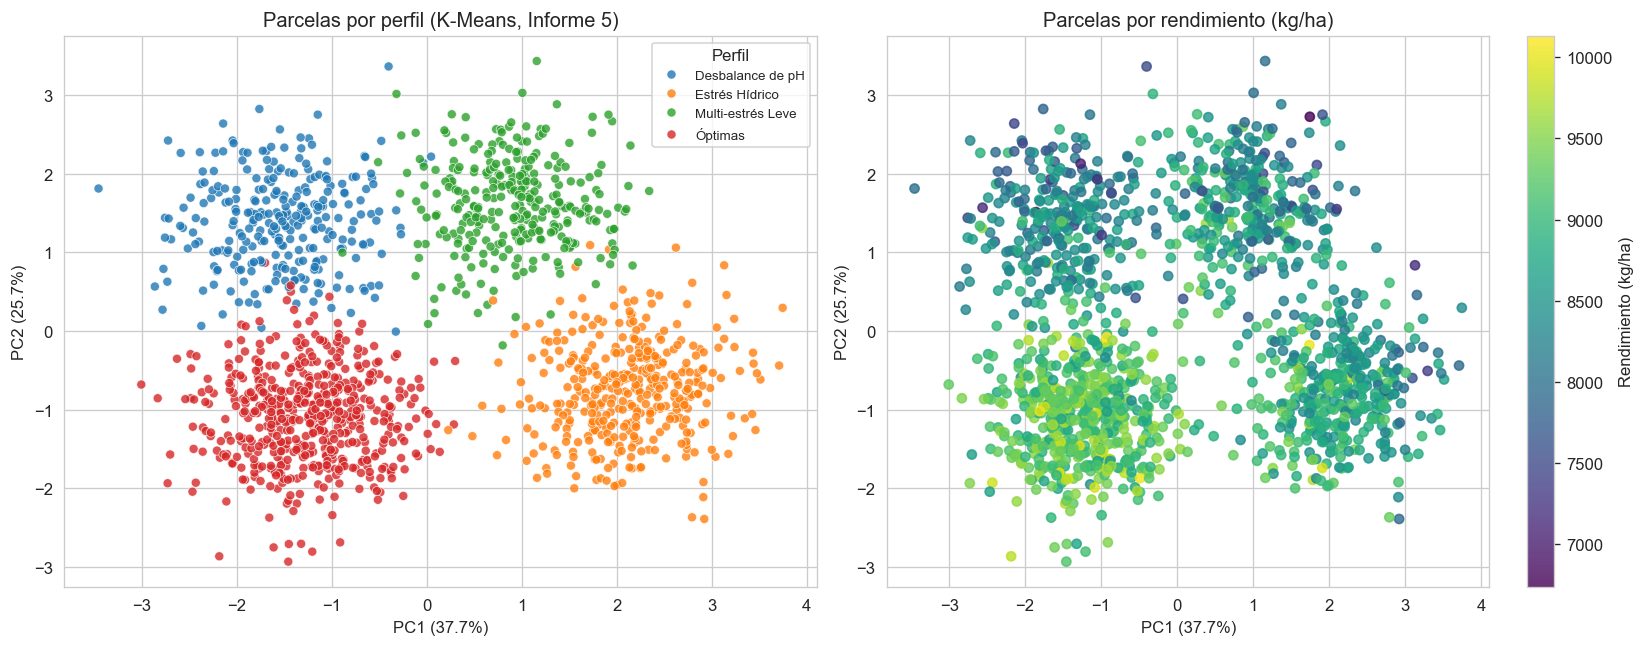

In [6]:
# Se proyectan las parcelas sobre los 2 primeros componentes y se colorean de dos formas:
#   - Por el perfil de parcela (los 4 grupos de K-Means del Informe 5).
#   - Por el rendimiento, para comprobar si el mapa refleja un gradiente de negocio.
pca_2d = PCA(n_components=2, random_state=SEED)
coords = pca_2d.fit_transform(X_scaled)

# Nombres de los perfiles según su interpretación agronómica (Informe 5)
nombres_perfil = {0: 'Óptimas', 1: 'Multi-estrés Leve',
                  2: 'Estrés Hídrico', 3: 'Desbalance de pH'}
df_pca = pd.DataFrame(coords, columns=['PC1', 'PC2'])
df_pca['perfil'] = pd.Series(grupos).map(nombres_perfil)
df_pca['rendimiento'] = df['rendimiento_kg_ha'].values

# Porcentaje de varianza que capta cada eje, para rotular los gráficos
pc1_var, pc2_var = pca_2d.explained_variance_ratio_ * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) Coloreado por perfil de parcela
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='perfil',
                palette='tab10', s=30, alpha=0.8, ax=ax1)
ax1.set_title('Parcelas por perfil (K-Means, Informe 5)')
ax1.set_xlabel(f'PC1 ({pc1_var:.1f}%)'); ax1.set_ylabel(f'PC2 ({pc2_var:.1f}%)')
ax1.legend(title='Perfil', fontsize=8)

# (b) Coloreado por rendimiento (gradiente continuo)
disp = ax2.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['rendimiento'],
                   cmap='viridis', s=30, alpha=0.8)
ax2.set_title('Parcelas por rendimiento (kg/ha)')
ax2.set_xlabel(f'PC1 ({pc1_var:.1f}%)'); ax2.set_ylabel(f'PC2 ({pc2_var:.1f}%)')
fig.colorbar(disp, ax=ax2, label='Rendimiento (kg/ha)')

plt.tight_layout()
plt.savefig('pca_proyeccion_2d.png', dpi=150, bbox_inches='tight')
plt.show()

### Observaciones de la proyección PCA

- Los cuatro perfiles de parcela ocupan cuadrantes bien diferenciados del plano PC1-PC2, con solapamiento mínimo. Esto confirma que dos componentes (63.5% de la varianza) bastan para conservar la estructura de grupos hallada en el Informe 5 sobre las siete variables originales.
- PC1 separa los perfiles por demanda hídrica: a la derecha (valores altos) quedan Estrés Hídrico y Multi-estrés Leve, con más calor y riego y menos humedad; a la izquierda, Óptimas y Desbalance de pH, más frescas y húmedas.
- PC2 separa los perfiles por manejo de suelo: arriba (valores altos) quedan Desbalance de pH y Multi-estrés Leve, con pH más alto y más fertilización; abajo, Óptimas y Estrés Hídrico.
- El mapa coloreado por rendimiento muestra un gradiente coherente: las parcelas Óptimas (cuadrante inferior izquierdo) concentran los rendimientos más altos, mientras que los perfiles con estrés tienden a rendimientos menores. Como el rendimiento no participó en el cálculo de los componentes, esta correspondencia confirma que los ejes capturan variación con sentido productivo real.

## 7. Proyección t-SNE en 2D

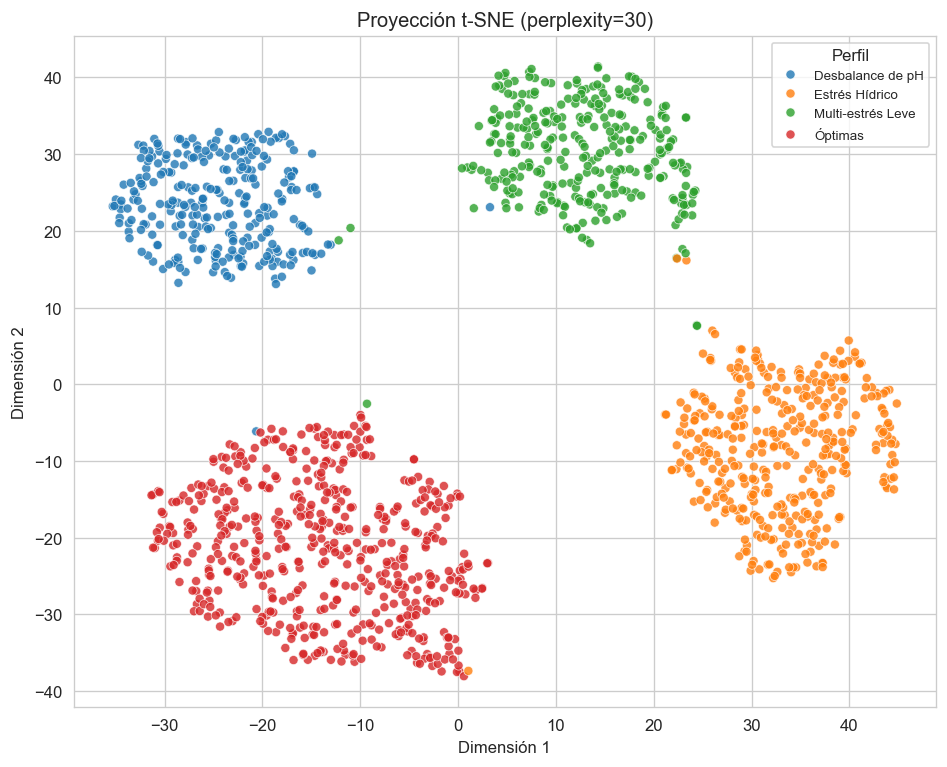

In [7]:
# t-SNE es una técnica no lineal orientada a visualización: preserva la estructura
# local (vecindades), a diferencia de PCA que preserva la varianza global.
# Como el espacio tiene solo 7 variables, se usa PCA a 5 componentes (91.8% de varianza).
X_pca_previo = PCA(n_components=5, random_state=SEED).fit_transform(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            init='pca', n_iter=1000, random_state=SEED)
coords_tsne = tsne.fit_transform(X_pca_previo)

df_tsne = pd.DataFrame(coords_tsne, columns=['Dim1', 'Dim2'])
df_tsne['perfil'] = pd.Series(grupos).map(nombres_perfil)

# Visualización coloreada por el perfil de parcela del Informe 5
plt.figure(figsize=(8, 6.5))
sns.scatterplot(data=df_tsne, x='Dim1', y='Dim2', hue='perfil',
                palette='tab10', s=30, alpha=0.8)
plt.title('Proyección t-SNE (perplexity=30)')
plt.xlabel('Dimensión 1'); plt.ylabel('Dimensión 2')
plt.legend(title='Perfil', fontsize=8)
plt.tight_layout()
plt.savefig('tsne_proyeccion_2d.png', dpi=150, bbox_inches='tight')
plt.show()

### Observaciones de la proyección t-SNE

- t-SNE separa los cuatro perfiles en regiones densas y claramente aisladas, con muy pocos puntos fuera de su grupo. La separación visual es más marcada que en PCA, coherente con que t-SNE está diseñado específicamente para resaltar la estructura de grupos.
- Solo unas pocas parcelas aparecen desplazadas hacia un grupo vecino (por ejemplo, algún punto verde o azul cerca de otra región). Corresponden a parcelas de frontera, con condiciones intermedias entre dos perfiles, las mismas que en el Informe 5 DBSCAN tendía a marcar como ruido.
- La nitidez de t-SNE confirma de forma independiente lo que ya mostraban las métricas del Informe 5 y la proyección PCA: existen cuatro perfiles reales de parcela, no una partición forzada.
- La posición y el tamaño de cada isla no deben interpretarse literalmente: t-SNE preserva la vecindad local, no las distancias globales ni la densidad real, por lo que la cercanía entre dos grupos en el gráfico no implica que sean más parecidos entre sí. Solo es fiable la separación en grupos, no la geometría entre ellos.

## 8. Comparación de PCA y t-SNE

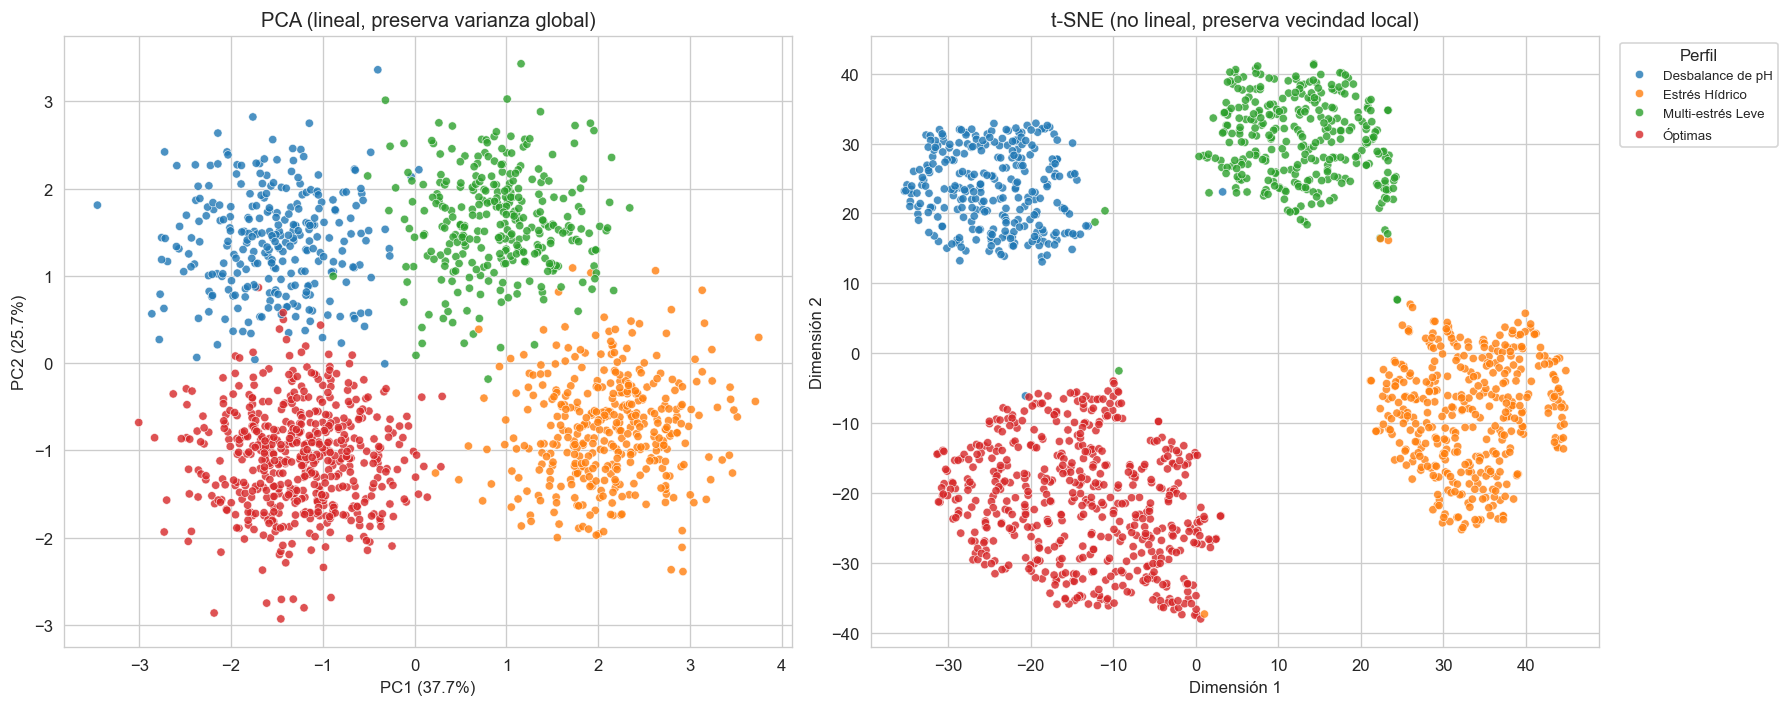

In [8]:
# Se colocan ambas proyecciones lado a lado para comparar cómo representa cada
# técnica los mismos perfiles de parcela: PCA (lineal, estructura global) frente
# a t-SNE (no lineal, estructura local).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='perfil',
                palette='tab10', s=25, alpha=0.8, ax=ax1, legend=False)
ax1.set_title('PCA (lineal, preserva varianza global)')
ax1.set_xlabel(f'PC1 ({pc1_var:.1f}%)'); ax1.set_ylabel(f'PC2 ({pc2_var:.1f}%)')

sns.scatterplot(data=df_tsne, x='Dim1', y='Dim2', hue='perfil',
                palette='tab10', s=25, alpha=0.8, ax=ax2)
ax2.set_title('t-SNE (no lineal, preserva vecindad local)')
ax2.set_xlabel('Dimensión 1'); ax2.set_ylabel('Dimensión 2')
ax2.legend(title='Perfil', fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('comparacion_pca_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

### Observaciones de la comparación

- Ambas técnicas recuperan los cuatro perfiles de parcela, lo que confirma que la estructura es real y no un artefacto de un método concreto.
- PCA conserva las relaciones globales: la posición relativa de los grupos es interpretable mediante los ejes (PC1 como demanda hídrica, PC2 como manejo de suelo), pero los grupos aparecen más juntos y con algo de solapamiento en las fronteras.
- t-SNE separa los grupos con mayor nitidez visual al comprimir cada perfil en una región densa, lo que facilita ver la cantidad de grupos, pero sus ejes no tienen interpretación directa y las distancias entre islas no son fiables.
- Para AndinaSense, ambas se complementan: PCA sirve para entender qué condiciones definen los perfiles y para comprimir la información, mientras que t-SNE es más útil como apoyo visual para comunicar de un vistazo que existen cuatro tipos de parcela diferenciados.

## 9. Conclusiones

- Las siete variables de condición de las parcelas se resumen en pocos factores: los tres primeros componentes principales concentran la caída fuerte de varianza (codo del scree plot y regla de Kaiser coinciden en 3), y con cinco componentes se retiene el 91.8% de la información. Esto evidencia redundancia entre las variables originales y confirma que las parcelas se describen bien en un espacio de menor dimensión.

- Los componentes tienen una lectura agronómica clara: PC1 representa la demanda hídrica (temperatura y riego frente a humedad de suelo), PC2 el manejo de suelo (pH y fertilización frente a horas de sol) y PC3 la intensidad del cultivo. Ningún componente depende de una sola variable, lo que muestra que las condiciones de las parcelas responden a factores compuestos.

- La reducción conserva la estructura del Informe 5: al proyectar sobre dos componentes (63.5% de la varianza), los cuatro perfiles de parcela ocupan cuadrantes diferenciados con solapamiento mínimo. Como el rendimiento, que no participó en el cálculo, se distribuye siguiendo un gradiente coherente sobre el mapa, se confirma que los ejes capturan variación con sentido productivo.

- PCA y t-SNE se complementan. PCA es lineal, interpretable mediante sus cargas y útil para compresión y preprocesamiento; t-SNE es no lineal y separa los grupos con mayor nitidez visual, aunque sus ejes y las distancias entre grupos no admiten interpretación directa. Ambas técnicas recuperan de forma independiente los cuatro perfiles, reforzando que la segmentación del Informe 5 refleja una estructura real.

- Valor para AndinaSense. La reducción de dimensionalidad permite representar en un solo mapa la distribución de las parcelas y comunicar los perfiles al equipo agronómico, además de identificar qué condiciones concentran la mayor variabilidad para priorizar las mediciones más informativas.

## Anexo de prompts
Nota: los prompts de generación del dataset sintético (compartido por los
Informes 3 a 6) se documentan en el anexo consolidado del proyecto.

| N° | Objetivo | Herramienta | Texto del prompt | Resultado | Ajuste |
|----|----------|-------------|------------------|-----------|--------|
| P-06.1 | Seleccionar el número de componentes con criterio, no por defecto | Claude Opus 4.8 | *Sobre mis 7 variables de condición ya estandarizadas quiero aplicar PCA y decidir cuántos componentes conservar con criterio técnico, no a ojo. El profe mencionó el umbral de varianza acumulada del 90%, pero quiero triangularlo con el codo del scree plot y la regla de Kaiser (autovalor > 1), teniendo claro que la regla de Kaiser usa el autovalor absoluto y no el ratio. Dame el código que reporte la varianza por componente, la acumulada y los tres criterios, y explícame por qué pueden apuntar a números distintos según el uso.* | Codo y Kaiser coinciden en 3 componentes; 5 componentes retienen el 91.8%; 2 para visualización | Verifiqué que los tres criterios no se contradicen: responden preguntas distintas (factores reales vs. información retenida vs. dimensiones graficables) |
| P-06.2 | Interpretar las cargas en términos agronómicos, no solo estadísticos | Claude Opus 4.8 | *Tengo la matriz de cargas (loadings) de mis 3 primeros componentes sobre las 7 variables de condición de parcela. Ayúdame a interpretar qué representa cada componente según qué variables pesan más y con qué signo, dándoles un nombre con sentido agronómico y no solo 'PC1, PC2'. Guíate por los pesos reales, no supongas.* | PC1 = demanda hídrica, PC2 = manejo de suelo, PC3 = intensidad del cultivo | Contrasté cada nombre con el signo y magnitud reales de las cargas antes de aceptarlo; ajusté la lectura de PC2 por el signo arbitrario del componente |
| P-06.3 | Demostrar la utilidad de la reducción proyectando los grupos del Informe 5 | Claude Opus 4.8 | *Quiero proyectar las parcelas sobre los 2 primeros componentes y colorearlas por los 4 perfiles de K-Means del Informe 5, para ver si la reducción conserva la estructura. Además quiero un segundo mapa coloreado por rendimiento, que NO debe entrar al PCA, solo colorear, para comprobar si los ejes tienen sentido productivo. Dame el código y recuérdame rotular cada eje con su porcentaje de varianza.* | Los 4 perfiles ocupan cuadrantes separados; el rendimiento forma un gradiente coherente sobre el mapa | Confirmé que el rendimiento se usó solo como color y nunca como entrada del PCA, respetando la separación entre predictores y resultado |
| P-06.4 | Aplicar t-SNE correctamente y sin sobreinterpretar el resultado | Claude Opus 4.8 | *Necesito t-SNE para visualizar mis parcelas en 2D. Sé que la buena práctica es reducir antes con PCA, pero mi espacio tiene solo 7 variables, así que dime a cuántos componentes reducir sin exagerar. Usa init='pca' y semilla fija para reproducibilidad, y adviérteme qué NO debo interpretar del gráfico (tamaños, distancias entre grupos) para no decir algo incorrecto en la sustentación.* | t-SNE separó los 4 perfiles en regiones densas y aisladas; PCA previo a 5 componentes | Ajusté el PCA previo a 5 componentes en lugar de los 30 del ejemplo del profe, porque con 7 variables pedir 30 no aplica; documenté que tamaños y distancias no se leen literalmente |